# **Image Reconstruction**

In [1]:
# Own modules
from src.utils import show_image, seed_all, MAE, save_model, load_model
from src.data_processing import download_dataset, get_dataset
from src.zhang_model import ZhangColorizationNet
from src.train import train
from src.evaluate import validate_zhang
from src.predict import predict_image_zhang


# Other libraries
import warnings
import os
import torch
import numpy as np
from tqdm import tqdm

# Paths
IMAGES_PATH = "images/"
DATA_PATH = "data/"
MODELS_PATH = "models/"
TEST_IMAGE_PATH = "data/test"

# seed
seed = 42
seed_all(seed)

In [2]:
# CONSTANTS
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
# Loss is weighted cross entropy loss
HYPERPARAMETERS = {
    "size": (256, 256),  # Image size
    "output_classes": 313, # quantized ab bins
    "optimizer": "adam",  # Optimizer
    "learning_rate": 1e-3,  # Learning rate
    "momentum": 0.9,  # Momentum
    "batch_size": 128,  # Batch size
    "epochs": 10,  # Number of epochs
    "num_workers": 4,  # Number of workers for data loading
    "scheduler": "StepLR",  # Learning rate scheduler
    "scheduler_step_size": 4,  # Step size for the scheduler
    "scheduler_gamma": 0.1,  # Gamma for the scheduler
}

**Loading the data**

In [4]:
train_dataset, val_dataset = get_dataset(DATA_PATH, HYPERPARAMETERS["size"], 0.1, "CIELab")

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
train_dataset.image_paths

Train dataset size: 27453
Validation dataset size: 3051


['data/train/100006.jpg',
 'data/train/100010.jpg',
 'data/train/100016.jpg',
 'data/train/100021.jpg',
 'data/train/10008.jpg',
 'data/train/100090.jpg',
 'data/train/100111.jpg',
 'data/train/100132.jpg',
 'data/train/100166.jpg',
 'data/train/100199.jpg',
 'data/train/100203.jpg',
 'data/train/100215.jpg',
 'data/train/10023.jpg',
 'data/train/100231.jpg',
 'data/train/100234.jpg',
 'data/train/100238.jpg',
 'data/train/100245.jpg',
 'data/train/100274.jpg',
 'data/train/100283.jpg',
 'data/train/100329.jpg',
 'data/train/100344.jpg',
 'data/train/100354.jpg',
 'data/train/10039.jpg',
 'data/train/10040.jpg',
 'data/train/100404.jpg',
 'data/train/100409.jpg',
 'data/train/100428.jpg',
 'data/train/100430.jpg',
 'data/train/100434.jpg',
 'data/train/100489.jpg',
 'data/train/100539.jpg',
 'data/train/100543.jpg',
 'data/train/100547.jpg',
 'data/train/100553.jpg',
 'data/train/10056.jpg',
 'data/train/100604.jpg',
 'data/train/100678.jpg',
 'data/train/100711.jpg',
 'data/train/1007

In [5]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=HYPERPARAMETERS["batch_size"],
    shuffle=True,
    num_workers=HYPERPARAMETERS["num_workers"],
)
val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=HYPERPARAMETERS["batch_size"],
    shuffle=False,
    num_workers=HYPERPARAMETERS["num_workers"],
)


**Create the pts_in_hull file**

In [6]:
# Lets create the points in hull file
train_dataset.get_pts_in_hull()

array([[-5.22636271e+00, -4.65804338e+00],
       [ 3.26604958e+01,  9.53054714e+00],
       [-6.74236449e-04,  1.27803953e-03],
       [ 1.10488701e+01, -5.52357197e-01],
       [ 1.57969911e-02, -1.53442430e+00],
       [-1.43587403e-03,  2.72145960e-03],
       [-1.76719844e+00,  6.62941360e+00],
       [ 3.13248386e+01,  3.54920616e+01],
       [-6.33651352e+00,  1.70760894e+00],
       [ 7.07526386e-01,  1.13461280e+00],
       [-1.29153585e+00, -2.44037457e+01],
       [-8.48631287e+00,  3.45207787e+01],
       [-1.25075397e+01,  9.40293121e+00],
       [-2.12315178e+00,  1.33962584e+00],
       [ 1.31525886e+00,  4.95680618e+00],
       [-8.36586638e-04,  1.58585527e-03],
       [-1.37593803e+01,  2.11955700e+01],
       [-1.05959344e+00, -3.51390696e+00],
       [ 2.20026951e+01, -2.96863961e+00],
       [ 2.43360925e+00, -1.14284248e+01],
       [ 6.58033419e+00,  1.19500790e+01],
       [ 9.48504031e-01,  2.20435596e+00],
       [ 6.89678431e-01, -2.80918956e+00],
       [-2.

In [9]:
Q = 313
bin_counts = np.zeros(Q)

subset_size = 5000  # or even 500–1000 for testing
sampled_indices = np.random.choice(len(train_dataset), subset_size, replace=False)

for i in tqdm(sampled_indices, desc="Computing class frequencies"):
    _, label_map = train_dataset[i]
    label_flat = label_map.numpy().flatten()
    bin_counts += np.bincount(label_flat, minlength=Q)
    

# Normalize to get empirical distribution
p_q = bin_counts / np.sum(bin_counts)

# Apply Zhang's smoothing formula
lambda_val = 0.5
w_q = (1 - lambda_val) * p_q + (lambda_val / Q)

# Invert and normalize
weights = 1 / w_q
weights = weights / (np.sum(weights) * Q)

# Save the weights
np.save("class_weights.npy", weights)


Computing class frequencies: 100%|██████████| 5000/5000 [05:04<00:00, 16.40it/s]


In [7]:
weights = np.load("class_weights.npy")

In [8]:
weights.shape

(313,)

**Train the model**

In [9]:
model = ZhangColorizationNet(
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=HYPERPARAMETERS["learning_rate"],
)
if HYPERPARAMETERS["scheduler"] == "StepLR":
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=HYPERPARAMETERS["scheduler_step_size"],
        gamma=HYPERPARAMETERS["scheduler_gamma"],
    )

# cross entropy loss with class weights
criterion = torch.nn.CrossEntropyLoss(
    weight=torch.from_numpy(weights).float().to(device),
    ignore_index=0,
)


In [10]:
model, train_hist, val_hist = train(
    model=model,
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=HYPERPARAMETERS["epochs"],
    scheduler=scheduler,
    device=device,
)



/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:156: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)



Epoch 1/10 completed in 669.43s
  Train Loss: 5.5897
  Validation Loss: 5.4198



Epoch 2/10 completed in 647.95s
  Train Loss: 5.3944
  Validation Loss: 5.3679



Epoch 3/10 completed in 648.80s
  Train Loss: 5.3681
  Validation Loss: 5.3426



Epoch 4/10 completed in 659.88s
  Train Loss: 5.3477
  Validation Loss: 5.3231


...


Epoch 6/10 completed in 645.53s
  Train Loss: 5.3139
  Validation Loss: 5.2973



Epoch 7/10 completed in 662.21s
  Train Loss: 5.2999
  Validation Loss: 5.2886



Epoch 8/10 completed in 669.61s
  Train Loss: 5.2885
  Validation Loss: 5.2653



Epoch 9/10 completed in 666.70s
  Train Loss: 5.2735
  Validation Loss: 5.2629



Epoch 10/10 completed in 654.00s
  Train Loss: 5.2631
  Validation Loss: 5.2431


In [11]:
# Create a random name for the model
import random
import string
import datetime
MODEL_NAME = "colorization_model_zhang" + datetime.datetime.now().strftime("%Y%m%d_%H%M%S") + "_" + ''.join(random.choices(string.ascii_lowercase, k=5))
# Save the model
save_model(model, os.path.join(MODELS_PATH, MODEL_NAME), MODEL_NAME, HYPERPARAMETERS)

Model saved at models/colorization_model_zhang20250421_170931_qahft/colorization_model_zhang20250421_170931_qahft.pth
Model parameters saved at models/colorization_model_zhang20250421_170931_qahft/colorization_model_zhang20250421_170931_qahft_params.json


In [10]:
MODEL_NAME = "colorization_model_zhang20250420_104819_fnafq"

In [12]:

# Load the model
model2 = ZhangColorizationNet().to(device)
model, _ = load_model(model2, os.path.join(MODELS_PATH, MODEL_NAME), MODEL_NAME)



**Prediction**

Prediction saved at models/pred_old_madrid.jpeg


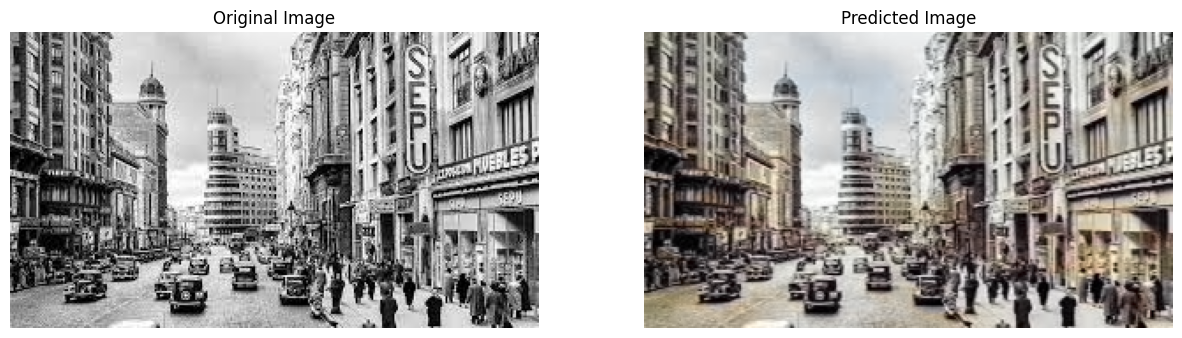

In [ ]:
from src.utils import show_image

test_image = "old_madrid.jpeg"

original_image, pred = predict_image_zhang(
    model=model2,
    image_path=os.path.join(TEST_IMAGE_PATH, test_image),
    device=device,
    size=HYPERPARAMETERS["size"],
)

# pass a path that saves the image in the models folder
show_image(original_image, pred, save_path=os.path.join(MODELS_PATH,MODEL_NAME, "pred_" + test_image))


Prediction saved at models/pred_real_madrid.jpg


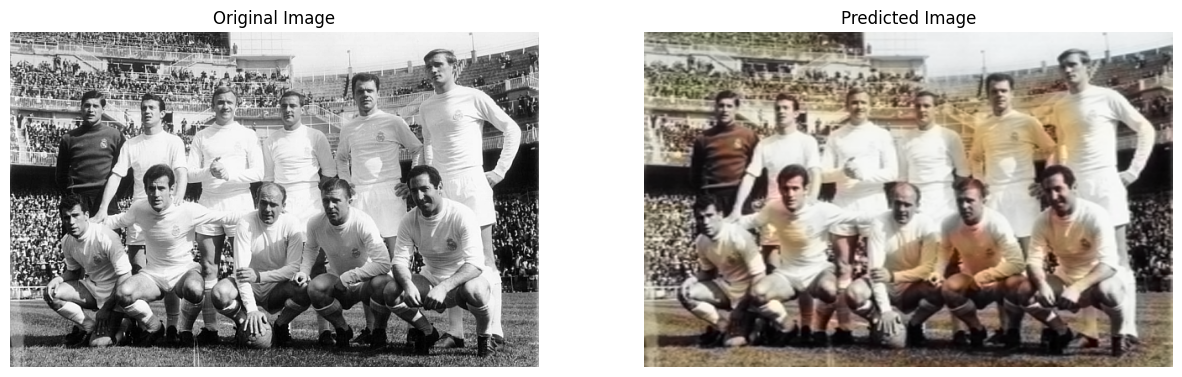

In [ ]:
test_image = "real_madrid.jpg"

original_image, pred = predict_image_zhang(
    model=model2,
    image_path=os.path.join(TEST_IMAGE_PATH, test_image),
    device=device,
    size=HYPERPARAMETERS["size"],
)

show_image(original_image, pred, save_path=os.path.join(MODELS_PATH,MODEL_NAME, "pred_" + test_image))

Prediction saved at models/pred_tesla.jpeg


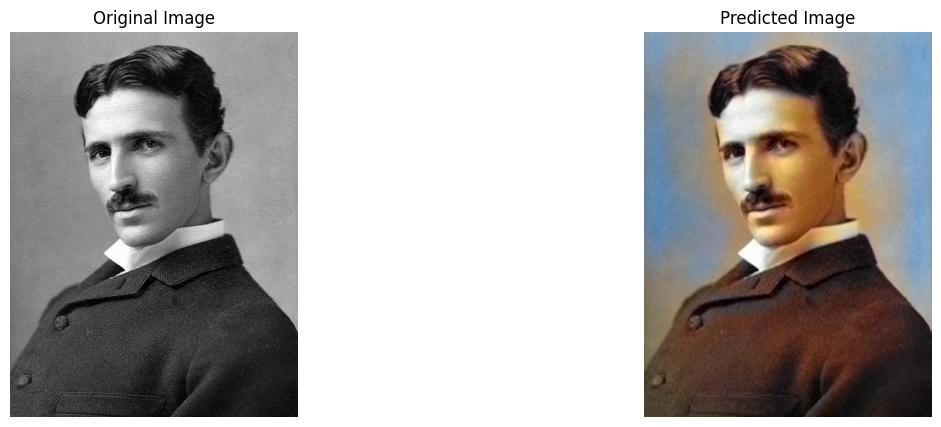

In [ ]:
test_image = "tesla.jpeg"

original_image, pred = predict_image_zhang(
    model=model2,
    image_path=os.path.join(TEST_IMAGE_PATH, test_image),
    device=device,
    size=HYPERPARAMETERS["size"],
)

show_image(original_image, pred, save_path=os.path.join(MODELS_PATH,MODEL_NAME, "pred_" + test_image))

Prediction saved at models/pred_dog.jpg


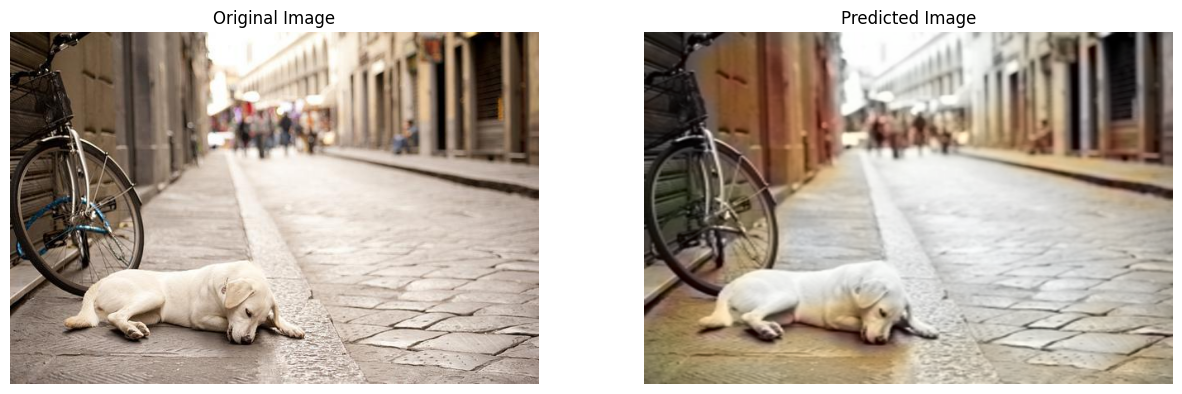

In [ ]:
test_image = "dog.jpg"

original_image, pred = predict_image_zhang(
    model=model2,
    image_path=os.path.join(TEST_IMAGE_PATH, test_image),
    device=device,
    size=HYPERPARAMETERS["size"],
)

show_image(original_image, pred, save_path=os.path.join(MODELS_PATH,MODEL_NAME, "pred_" + test_image))

Prediction saved at models/pred_rafa_nadal.jpg


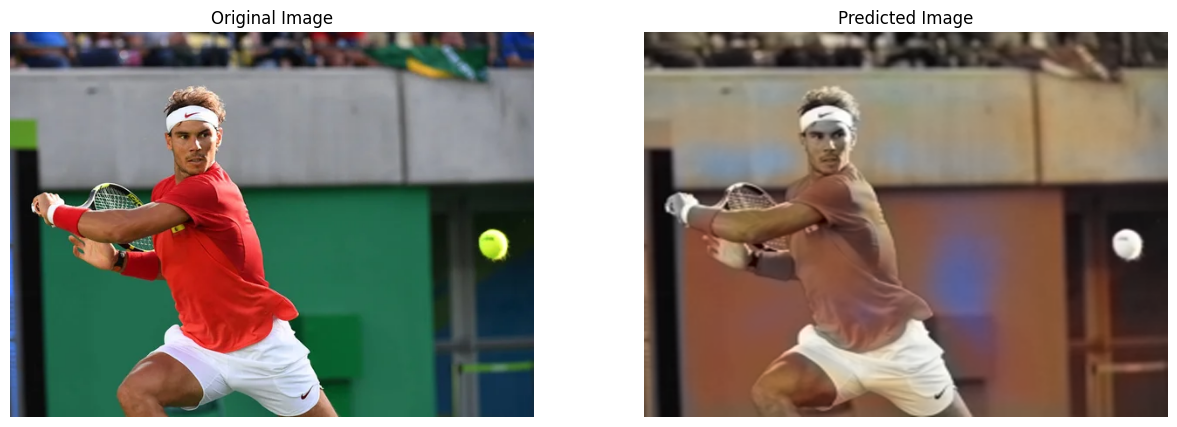

In [ ]:
test_image = "rafa_nadal.jpg"

original_image, pred = predict_image_zhang(
    model=model2,
    image_path=os.path.join(TEST_IMAGE_PATH, test_image),
    device=device,
    size=HYPERPARAMETERS["size"],
)

show_image(original_image, pred, save_path=os.path.join(MODELS_PATH, MODEL_NAME, "pred_" + test_image))